# Introduction

Globally, mental health is a growing concern in the United States and around the world. It is estimated that one in five U.S. adults experience mental illness each year and one in six U.S. youth, ages 6-17, experience mental health disorders each year2. This is especially concerning since Suicide is the 2nd leading cause of death among people ages 10-142. These are preventable deaths that should never happen. 
The primary goal of the analysis is to familiarize ourselves with the various mental health classes and to identify patterns. Our objective is to visualize the distribution of the mental health statuses, evaluate the length of the statements per class, explore frequently used words through word clouds, and accurately predict the mental health statuses for each statement.

# Data Description

The data is a collection of mental health statuses tagged from various statements collected from many other mental health datasets on Kaggle. It contains 53,042 rows and three columns. Each row contains a mental health statement where each row represents a unique individual comment.

# Loading Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import gc
import re
import os
import numpy as np

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from huggingface_hub import login
from datasets import Dataset
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from transformers import pipeline
from wordcloud import WordCloud
from kaggle_secrets import UserSecretsClient

In [2]:
def remove_patterns(text):
    if not isinstance(text, str):
        return ""
    # Remove URLs
    text = re.sub(r'http[s]?://\S+', '', text)
    # Remove markdown-style links
    text = re.sub(r'\[.*?\]\(.*?\)', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [3]:
# Load the data and preprocess
df = pd.read_csv('/kaggle/input/sentiment-analysis-for-mental-health/Combined Data.csv')
df = df.drop(columns=['Unnamed: 0'], axis=1)
df['statement']=df['statement'].str.lower()
# Apply the function to the 'statement' column
df['statement'] = df['statement'].apply(remove_patterns)

df = df[df['statement'].str.strip() != ""]
df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"all wrong, back off dear, forward doubt. stay ...",Anxiety
3,i've shifted my focus to something else but i'...,Anxiety
4,"i'm restless and restless, it's been a month n...",Anxiety


# Exploratory Data Analysis

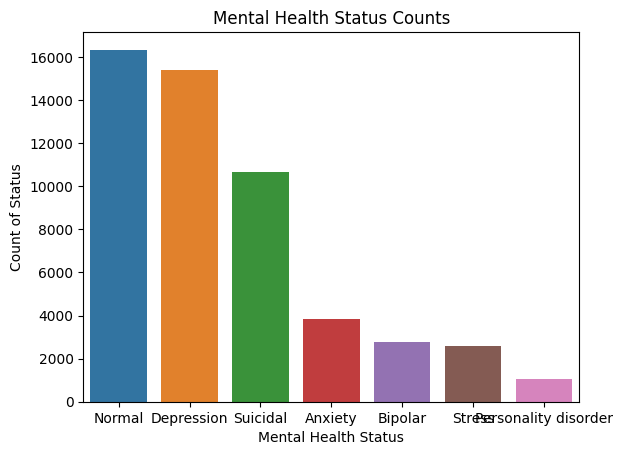

In [4]:
# Plotting status counts
sns.countplot(data=df, x='status', order=list(df['status'].value_counts().index))
plt.xlabel('Mental Health Status')
plt.ylabel('Count of Status')
plt.title('Mental Health Status Counts')
plt.show()

From the count plot we can see a majority of cases are Normal, Depression, and Suicidal. 

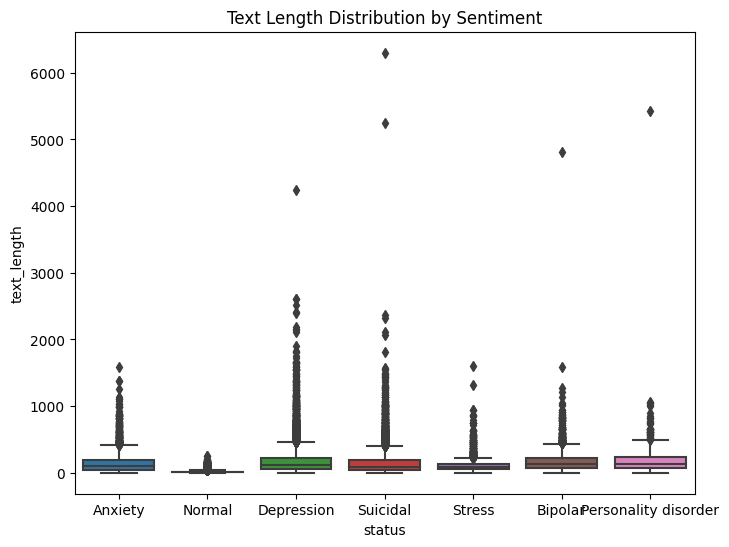

In [5]:
# Fill NaN values in 'statement' column with empty string
df['statement'] = df['statement'].fillna('')

df['text_length'] = df['statement'].apply(lambda x: len(x.split()))

# Plot distribution of statement length for each status
plt.figure(figsize=(8, 6))
sns.boxplot(x='status', y='text_length', data=df)
plt.title('Text Length Distribution by Sentiment')
plt.show()

From the above chart we can see there are some outlier statements with very long text lengths. A majority of statements are below 3,000. We can also see the Normal class has the shortest text lengths overall.

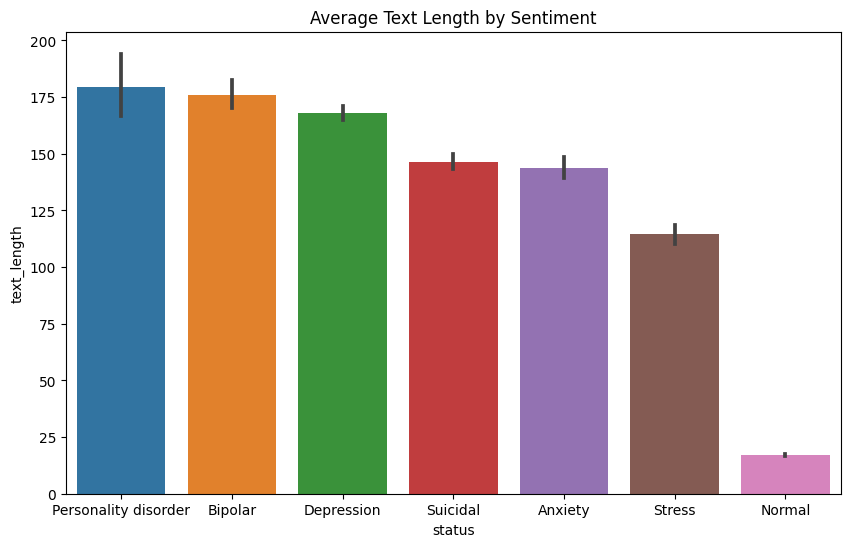

In [6]:
# Average length by status bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x='status', y='text_length', data=df, order= df.groupby('status')['text_length'].mean().sort_values(ascending=False).index)
plt.title('Average Text Length by Sentiment')
plt.show()

From the above chart we can see the statements classified as Normal have the least average text length, while statement with mental health problems tend to have longer statements on average.

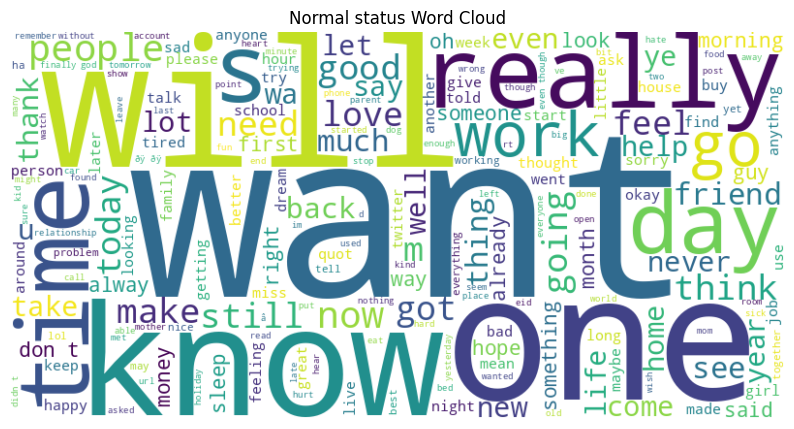

In [7]:
# Generate word cloud for a status classes
normal_text = ' '.join(df[df['status'] == 'Normal']['statement'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(normal_text)

plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.title('Normal status Word Cloud')
plt.axis('off')
plt.show()

Nothing really stands out to me as an indicator of the Normal class in the above word cloud visualization. 

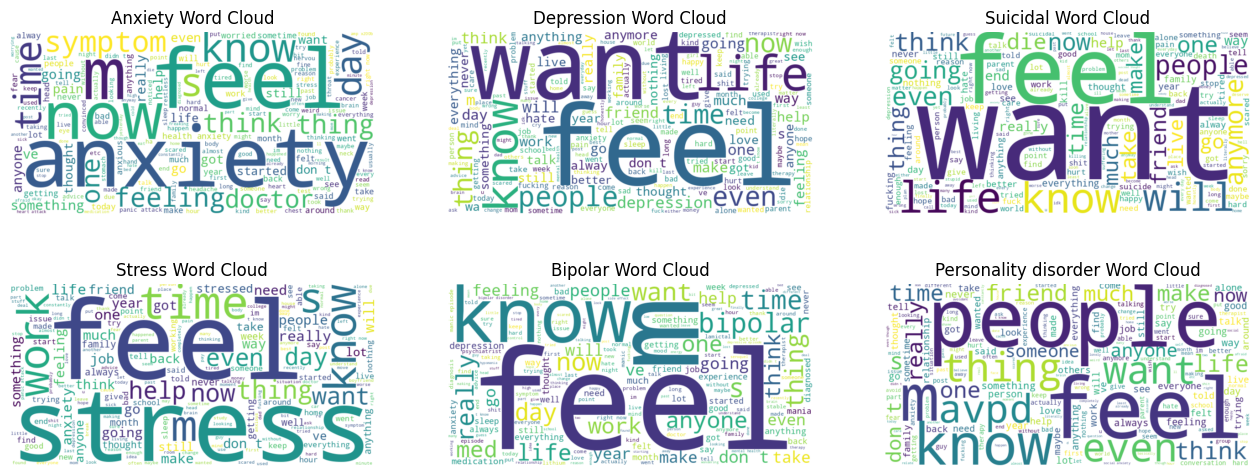

In [8]:
# Generate word cloud for status classes
fig, ax = plt.subplots(2, 3, figsize=(16, 6))

# Get unique statuses excluding 'Normal'
statuses = df[df['status'] != 'Normal']['status'].unique()

for i, status in enumerate(statuses):
    # Combine all statements for the current status
    text = ' '.join(df[df['status'] == status]['statement'])
    
    # Generate word cloud
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    
    # Display word cloud
    ax[i//3, i%3].imshow(wordcloud, interpolation='bilinear')
    ax[i//3, i%3].set_title(f'{status} Word Cloud')
    ax[i//3, i%3].axis('off')
plt.show()

The above word clouds don't give me too much insight. The main thing I notice from all the classes with mental health issue is "feel", "know", and the words of their classification showing up in the clouds. 

# Modeling

In [9]:
df.drop(['text_length'], axis=1, inplace=True)
df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"all wrong, back off dear, forward doubt. stay ...",Anxiety
3,i've shifted my focus to something else but i'...,Anxiety
4,"i'm restless and restless, it's been a month n...",Anxiety


In [10]:
dataset = Dataset.from_pandas(df)

# Initialize pipeline
classifier = pipeline('zero-shot-classification', model='facebook/bart-large-mnli', device=0)

# Define candidate labels
candidate_labels = ['Normal', 'Depression', 'Suicidal', 'Anxiety', 'Bipolar', 'Stress', 'Personality disorder']

# Run classification in batch
def classify(batch):
    results = classifier(batch['statement'], candidate_labels=candidate_labels)
    return {'status_label': [r['labels'][0] for r in results]}

# Apply function
dataset = dataset.map(classify, batched=True, batch_size=32)

# Convert back to DataFrame
df = dataset.to_pandas()

# Evaluate
from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(df['status'], df['status_label']))

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


Map:   0%|          | 0/52680 [00:00<?, ? examples/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Accuracy: 0.37813211845102507


<Figure size 800x600 with 0 Axes>

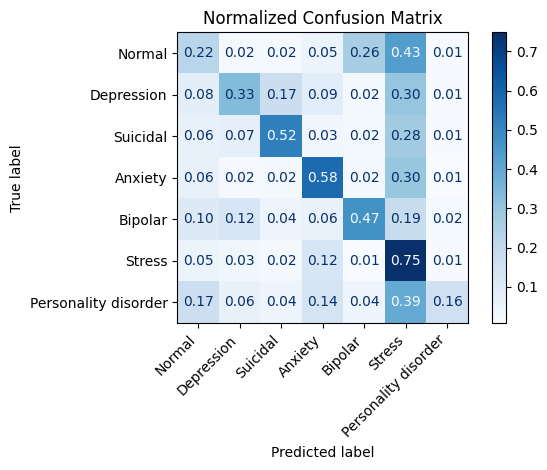

In [11]:
# Compute normalized confusion matrix
cm = confusion_matrix(df['status'], df['status_label'], labels=candidate_labels, normalize='true')

# Display normalized confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=candidate_labels)

plt.figure(figsize=(8, 6))
disp.plot(cmap="Blues", values_format=".2f")
plt.xticks(rotation=45, ha='right')
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

From the above chart we can see that this model predicted a majority of the statements to be Stress even though it is the second to last common label. This model also struggled to identify the Normal class showing it failed to identify differences between Normal and classes with a mental health label.

In [12]:
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")

os.environ["WANDB_DISABLED"] = "true"
login(token=hf_token)

# Encode labels
labels = df['status'].unique().tolist()
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for label, i in label2id.items()}
df['label'] = df['status'].map(label2id)

# Convert to Hugging Face Dataset
dataset = Dataset.from_pandas(df)

# Tokenizer from the mental health BERT model
model_name = "nateraw/bert-base-uncased-emotion"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Tokenize text
def tokenize(batch):
    return tokenizer(batch['statement'], truncation=True, padding=True)

dataset = dataset.map(tokenize, batched=True)

# Split into train/test sets
dataset = dataset.train_test_split(test_size=0.2)
train_dataset = dataset["train"]
test_dataset = dataset["test"]

# Load the model
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True
)

# Training arguments
training_args = TrainingArguments(
    output_dir="./mental-health-model",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    logging_dir='./logs',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy'
)

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {'accuracy': accuracy_score(predictions, labels)}

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

# Fine-tune the model
trainer.train()

# Evaluate
metrics = trainer.evaluate()
trainer.predict(test_dataset).metrics

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/768 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/52680 [00:00<?, ? examples/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at nateraw/bert-base-uncased-emotion and are newly initialized because the shapes did not match:
- classifier.weight: found shape torch.Size([6, 768]) in the checkpoint and torch.Size([7, 768]) in the model instantiated
- classifier.bias: found shape torch.Size([6]) in the checkpoint and torch.Size([7]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).
<ipython-input-12-c0e4bce331a8>:60: Fut

Epoch,Training Loss,Validation Loss,Accuracy
1,0.475000,0.470264,0.817198
2,0.350300,0.435009,0.836845
3,0.227200,0.519984,0.841211
4,0.129300,0.694961,0.836181


{'test_loss': 0.5199843049049377,
 'test_accuracy': 0.8412110858010631,
 'test_runtime': 170.1453,
 'test_samples_per_second': 61.924,
 'test_steps_per_second': 3.873}

In [13]:
# Get predictions
pred_output = trainer.predict(test_dataset)
y_pred = np.argmax(pred_output.predictions, axis=1)
y_true = pred_output.label_ids

<Figure size 800x600 with 0 Axes>

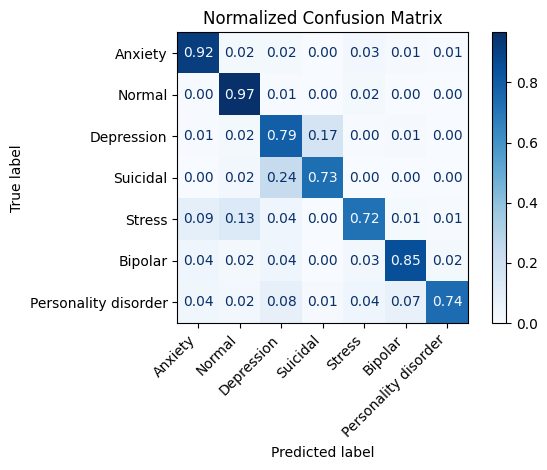

In [14]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(id2label.keys()), normalize='true')

# Display normalized confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(id2label.values()))

plt.figure(figsize=(8, 6))
disp.plot(cmap="Blues", values_format=".2f")
plt.xticks(rotation=45, ha='right')
plt.title("Normalized Confusion Matrix")
plt.tight_layout()
plt.show()

In the confusion matrix above we can see the model had a slight problem differentiating between the Depression and Suicidal classes but did very well with the remaining classes. The model classified the Normal class the most accurately which shows the model was able to differentiate the Normal class the remaining classes with mental health problems with a low misclassification rate.

# Conclusion

Mental health is growing concern in our country and across the world. Through our exploratory data analysis, we were able to point out the most common mental health conditions in our data as well as common traits in the statements given by the individuals in our data.

A high accuracy score was acheived with with a model pre-trained on mental health data and fine-tuned for our specific use case from hugging face.

Mental health classification models like the one we built in this report can be used for early detection of signs of distress, depression, and anxiety from text that would allow for earlier professional intervention. Schools, workplaces, or healthcare systems are some potential industries that could benefit from a system like this to give students, employees, or patients support.